In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from sklearn.datasets import make_blobs

In [3]:
X, y = make_blobs(n_samples=[10,20],n_features = 2,centers=[[-0.5,-1.0],[+0.5,+1.0]])
X = np.hstack((X, np.ones((30,1))))
X,y

(array([[ 3.58307503e-01,  1.08283453e+00,  1.00000000e+00],
        [ 6.90363041e-01, -6.09279932e-01,  1.00000000e+00],
        [ 4.58951789e-01, -2.22514725e-01,  1.00000000e+00],
        [-2.62788950e-01, -3.40232647e+00,  1.00000000e+00],
        [ 1.90229492e+00,  1.57819654e+00,  1.00000000e+00],
        [-5.22733045e-01, -1.79727593e-02,  1.00000000e+00],
        [-1.05377350e+00,  7.77299361e-01,  1.00000000e+00],
        [-2.86160908e-01,  2.23073208e-01,  1.00000000e+00],
        [ 1.48678953e+00, -6.32027561e-01,  1.00000000e+00],
        [ 4.86879955e-02,  2.21891782e+00,  1.00000000e+00],
        [ 1.52314422e+00,  3.92661210e-01,  1.00000000e+00],
        [-2.44997768e-03, -1.68499993e+00,  1.00000000e+00],
        [-8.05960805e-01, -2.28475077e+00,  1.00000000e+00],
        [ 4.50664116e-01, -9.18354213e-01,  1.00000000e+00],
        [-3.58368360e-02,  4.74257663e-01,  1.00000000e+00],
        [ 1.22425599e+00, -1.06055870e-01,  1.00000000e+00],
        [ 5.60520412e-01

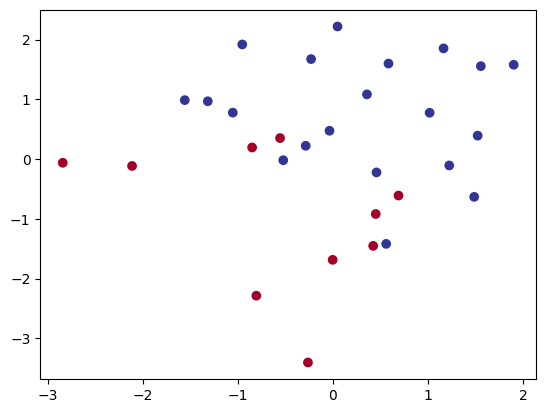

In [4]:
plt.scatter(X[:,0],X[:,1],c=y,cmap='RdYlBu')
plt.show()

In [5]:
X

array([[ 3.58307503e-01,  1.08283453e+00,  1.00000000e+00],
       [ 6.90363041e-01, -6.09279932e-01,  1.00000000e+00],
       [ 4.58951789e-01, -2.22514725e-01,  1.00000000e+00],
       [-2.62788950e-01, -3.40232647e+00,  1.00000000e+00],
       [ 1.90229492e+00,  1.57819654e+00,  1.00000000e+00],
       [-5.22733045e-01, -1.79727593e-02,  1.00000000e+00],
       [-1.05377350e+00,  7.77299361e-01,  1.00000000e+00],
       [-2.86160908e-01,  2.23073208e-01,  1.00000000e+00],
       [ 1.48678953e+00, -6.32027561e-01,  1.00000000e+00],
       [ 4.86879955e-02,  2.21891782e+00,  1.00000000e+00],
       [ 1.52314422e+00,  3.92661210e-01,  1.00000000e+00],
       [-2.44997768e-03, -1.68499993e+00,  1.00000000e+00],
       [-8.05960805e-01, -2.28475077e+00,  1.00000000e+00],
       [ 4.50664116e-01, -9.18354213e-01,  1.00000000e+00],
       [-3.58368360e-02,  4.74257663e-01,  1.00000000e+00],
       [ 1.22425599e+00, -1.06055870e-01,  1.00000000e+00],
       [ 5.60520412e-01, -1.41811790e+00

In [6]:
def logistic(x):
    return 1 / (1+np.exp(-x))

# logistic(np.array([-2000,-1,0,1,2000]))

In [7]:
theta = np.zeros(X.shape[1])
costs= []
alpha=0.5

for _ in range(1000):
    yhat = logistic(X @ theta)
    error = yhat - y
    theta = theta -alpha/len(y) * X.T@error
    cost = 1/len(y)*np.sum(-y * np.log(yhat) -(1.0-y)*np.log(1.0-yhat))
    costs.append(cost)
    
theta

array([1.81256312, 2.75861523, 1.20468535])

In [33]:
from sklearn.linear_model import LogisticRegression

In [34]:
model = LogisticRegression(fit_intercept =False, penalty=None)
model.fit(X,y)

LogisticRegression(fit_intercept=False, penalty=None)

In [35]:
model.coef_

array([[2.50543173, 2.54743942, 0.63847791]])

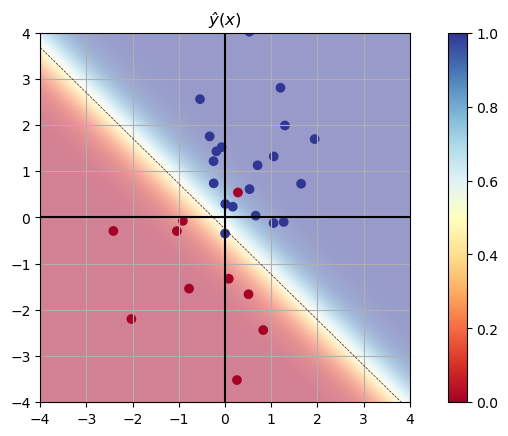

In [36]:
xx1, xx2 = np.meshgrid(np.linspace(-4.0, 4.0, 81), np.linspace(-4.0, 4.0, 81))
XX = np.array([xx1.ravel(), xx2.ravel(), np.ones(xx1.size)]).T
yy = logistic(XX @ theta).reshape(xx1.shape)

plt.grid(True); plt.axhline(0.0, c='k'); plt.axvline(0.0, c='k')
plt.imshow(yy, extent=(-4.0, 4.0, -4.0, 4.0), origin='lower', interpolation='bilinear', cmap='RdYlBu', vmin=0.0, vmax=1.0, alpha=0.5)
plt.contour(xx1, xx2, yy, [0.5], linewidths=0.5, linestyles='dashed')
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='RdYlBu')
plt.colorbar()
plt.title('$ŷ(x)$')
plt.axis('square'); plt.axis((-4.0, 4.0, -4.0, 4.0))
plt.show()